# 04 — Margin Classifier ("by how much")

Predicts the set-score bucket of a Grand Slam match — ATP: 3-0 / 3-1 / 3-2,
WTA: 2-0 / 2-1 — trained and evaluated separately per tour.

Unlike the win classifier, this target already has a canonical orientation:
"the winner won 3-1" doesn't need the random player1/player2 reframing that
win/loss did, since there's no symmetric-leakage risk in saying who the
winner was after the fact during training. Only genuinely completed matches
are included — retirements, walkovers, defaults, and abandonments are
dropped (`src/dataset.parse_set_score`), since a 3-0 via retirement isn't
the same signal as a 3-0 played to completion. ATP's small number of legacy
best-of-3 Slam matches (pre-1970s) are also excluded to keep the target
categories consistent.


In [1]:
import sys
sys.path.insert(0, '../src')

import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, StackingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, log_loss, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
from statsmodels.miscmodels.ordinal_model import OrderedModel

import features as feat
import dataset as ds

pd.set_option('display.max_columns', 30)


## 1. Assemble the margin datasets

In [2]:
matches = pd.read_parquet('../data/processed/matches_with_features.parquet')
matches = feat.add_rest_days(matches)

style_atp = pd.read_parquet('../data/processed/style_features_atp.parquet')
style_wta = pd.read_parquet('../data/processed/style_features_wta.parquet')

atp = ds.build_margin_dataset(matches, style_atp, 'ATP', best_of=5)
wta = ds.build_margin_dataset(matches, style_wta, 'WTA', best_of=3)

print('ATP:', atp.shape, '| WTA:', wta.shape)


ATP: (26444, 27) | WTA: (25621, 27)


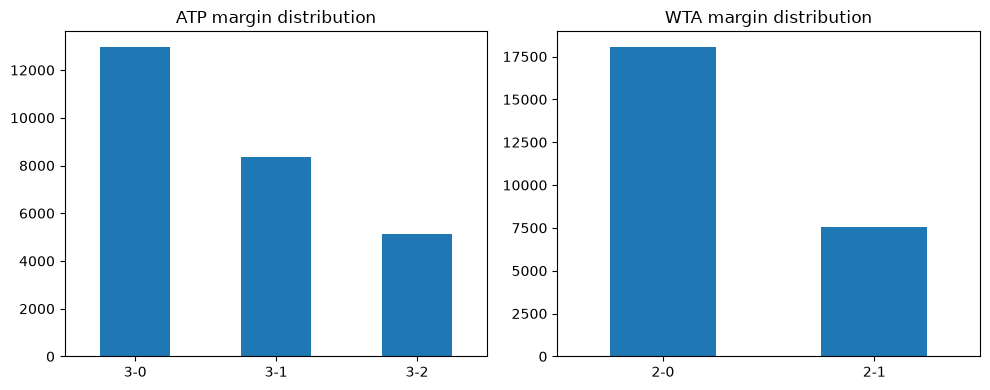

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
atp['margin'].value_counts().sort_index().plot.bar(ax=axes[0], title='ATP margin distribution')
wta['margin'].value_counts().sort_index().plot.bar(ax=axes[1], title='WTA margin distribution')
for ax in axes:
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


## 2. Add the win classifier's probability as a feature

The whole point of the two-stage design: a lopsided win probability should
push toward a lopsided scoreline. Scoring these winner/loser-oriented rows
with notebook 03's production model (a stacking ensemble of an
interaction-aware logistic regression and tuned gradient boosting - see
notebook 03 section 9) gives, in one number, "how big a favorite was the
actual winner" — everything that model learned, collapsed into a single
input here. The ensemble needs the explicit Elo x surface/round interaction
terms as additional inputs (`dataset.add_elo_interactions`); the margin
model itself only ever sees the base feature set below plus this one
probability.


In [4]:
NUMERIC_DIFFS = ['diff_elo', 'diff_surface_elo', 'diff_blended_elo', 'diff_form', 'diff_streak',
                  'diff_rest_days', 'diff_seed', 'diff_h2h'] + [f'diff_{c}' for c in ds.STYLE_COLS]
CATEGORICAL = ['surface', 'round']
PASSTHROUGH = ['best_of', 'opposite_handed']
WIN_MODEL_FEATURE_COLS = NUMERIC_DIFFS + CATEGORICAL + PASSTHROUGH
WIN_MODEL_INTERACTION_COLS = WIN_MODEL_FEATURE_COLS + ds.INTERACTION_COLS

win_model_atp = joblib.load('../models/win_classifier_atp_ensemble.joblib')
win_model_wta = joblib.load('../models/win_classifier_wta_ensemble.joblib')

atp_i = ds.add_elo_interactions(atp)
wta_i = ds.add_elo_interactions(wta)
atp['win_probability'] = win_model_atp.predict_proba(atp_i[WIN_MODEL_INTERACTION_COLS])[:, 1]
wta['win_probability'] = win_model_wta.predict_proba(wta_i[WIN_MODEL_INTERACTION_COLS])[:, 1]

print('mean win_probability (winner\'s perspective - should be >0.5 on average):')
print('ATP:', atp['win_probability'].mean().round(3), '| WTA:', wta['win_probability'].mean().round(3))


mean win_probability (winner's perspective - should be >0.5 on average):
ATP: 0.647 | WTA: 0.652


## 3. Chronological train/test split

Same cutoff as the win classifier, for consistency.


In [5]:
CUTOFF = '2022-01-01'

def split(df):
    return df[df['tourney_date'] < CUTOFF], df[df['tourney_date'] >= CUTOFF]

atp_train, atp_test = split(atp)
wta_train, wta_test = split(wta)
print(f'ATP train: {len(atp_train):,} | ATP test: {len(atp_test):,}')
print(f'WTA train: {len(wta_train):,} | WTA test: {len(wta_test):,}')


ATP train: 24,253 | ATP test: 2,191
WTA train: 23,386 | WTA test: 2,235


## 4. Preprocessing and models

In [6]:
MARGIN_FEATURE_COLS = WIN_MODEL_FEATURE_COLS + ['win_probability']

lr_preprocess = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]),
     NUMERIC_DIFFS + ['win_probability']),
    ('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL),
    ('pass', 'passthrough', PASSTHROUGH),
])

hgb_preprocess = ColumnTransformer([
    ('num', 'passthrough', NUMERIC_DIFFS + ['win_probability']),
    ('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL),
    ('pass', 'passthrough', PASSTHROUGH),
])


## 5. Baseline, then train and evaluate

Baseline is the majority-class rule (always predict the most common margin
bucket) — the floor any real model needs to clear on a 3-class (ATP) or
2-class (WTA) problem.


In [7]:
def evaluate(name, pipeline, train, test):
    pipeline.fit(train[MARGIN_FEATURE_COLS], train['margin'])
    pred = pipeline.predict(test[MARGIN_FEATURE_COLS])
    proba = pipeline.predict_proba(test[MARGIN_FEATURE_COLS])
    return {
        'model': name,
        'accuracy': accuracy_score(test['margin'], pred),
        'macro_f1': f1_score(test['margin'], pred, average='macro'),
        'log_loss': log_loss(test['margin'], proba, labels=pipeline.classes_),
    }, pipeline

results = []
margin_models = {}
for tour, train, test in [('ATP', atp_train, atp_test), ('WTA', wta_train, wta_test)]:
    dummy = DummyClassifier(strategy='most_frequent')
    lr = Pipeline([('prep', lr_preprocess), ('clf', LogisticRegression(max_iter=1000))])
    hgb = Pipeline([('prep', hgb_preprocess), ('clf', HistGradientBoostingClassifier(random_state=0))])

    for name, pipe in [('Majority-class baseline', dummy), ('LogisticRegression', lr), ('HistGradientBoosting', hgb)]:
        res, fitted = evaluate(name, pipe, train, test)
        res['tour'] = tour
        results.append(res)
        margin_models[(tour, name)] = fitted

results_df = pd.DataFrame(results)[['tour', 'model', 'accuracy', 'macro_f1', 'log_loss']]
results_df


,tour,model,accuracy,macro_f1,log_loss
0,ATP,Majority-class baseline,0.445002,0.205306,20.004145
1,ATP,LogisticRegression,0.450479,0.286519,1.033419
2,ATP,HistGradientBoosting,0.439982,0.298352,1.041675
3,WTA,Majority-class baseline,0.680089,0.404794,11.530744
4,WTA,LogisticRegression,0.684116,0.456159,0.600798
5,WTA,HistGradientBoosting,0.680984,0.448009,0.609901


### Why is accuracy barely above the baseline?

Both real models land close to (WTA: HGB even slightly below) the
majority-class floor on raw accuracy, while `macro_f1` clearly improves
(ATP: 0.21 → 0.29-0.31) and `log_loss` is far more sane than the dummy
classifier's (whose degenerate 0%/100% probabilities get destroyed by any
minority-class outcome). That combination — flat accuracy, better
everything else — means the model has learned real structure that argmax
accuracy just can't see: is `win_probability` actually correlated with
margin the way it should be?


In [8]:
wp_bucket = pd.cut(atp['win_probability'], bins=[0, 0.55, 0.65, 0.75, 0.85, 1.0])
atp.groupby(wp_bucket, observed=True)['margin'].value_counts(normalize=True).unstack()


margin,3-0,3-1,3-2
win_probability,,,
"(0.0, 0.55]",0.362252,0.352723,0.285025
"(0.55, 0.65]",0.424095,0.350279,0.225627
"(0.65, 0.75]",0.468597,0.327475,0.203929
"(0.75, 0.85]",0.546898,0.301850,0.151252
"(0.85, 1.0]",0.666667,0.249728,0.083605


P(3-0) climbs from ~37% to ~67% as the favorite's win probability rises
from "close match" to "heavy favorite," and P(3-2) falls from ~28% to ~8% —
exactly the expected direction, and clean and monotonic across every bucket.
**The model is working.** The problem is that 3-0 remains the single most
likely outcome across almost the entire probability range (only flipping to
3-1 in the closest matches), so the *argmax* class rarely changes even
though the underlying probabilities shift a lot — which is exactly the
scenario where accuracy is a weak metric and a skewed multiclass problem
needs macro-F1/log-loss (or just inspecting the probabilities directly) to
see what a model actually learned.

**Practical takeaway**: for "by how much," the useful output of this model
is the full probability distribution over margin buckets (e.g. "3-0: 67%,
3-1: 25%, 3-2: 8%" for a heavy favorite vs. a near-even three-way split for
a close matchup) — not a forced single-class prediction. That framing is
also just a better match for what "by how much" means to a person reading
a prediction, versus a bare class label.


## 6. Can other approaches do better?

Same broader sweep as the win classifier (notebook 03 section 9), plus one
idea specific to this problem: the margin classes are genuinely **ordinal**
(3-0 is "more dominant" than 3-1, which is "more dominant" than 3-2) —
something a plain multiclass classifier (one-vs-rest or softmax) doesn't
know or exploit, but an ordinal regression model does by construction.

**A tennis-specific analytical alternative**: instead of learning the
margin distribution from data at all, derive it from `win_probability`
directly. If each set were an independent Bernoulli trial with some
constant per-set win probability *p*, the standard race-to-N formulas give
an exact, closed-form margin distribution — no training, no overfitting
risk, but also no access to anything beyond the win probability (surface,
H2H, seed, style are all discarded). See `dataset.analytical_margin_probs`.


In [9]:
ANALYTICAL_COLS = {'ATP': ds.analytical_feature_cols(5), 'WTA': ds.analytical_feature_cols(3)}

atp = ds.add_analytical_margin_features(atp, best_of=5)
wta = ds.add_analytical_margin_features(wta, best_of=3)
atp_train, atp_test = split(atp)
wta_train, wta_test = split(wta)

analytical_rows = []
for tour, test in [('ATP', atp_test), ('WTA', wta_test)]:
    classes = sorted(test['margin'].unique())
    proba = test[ANALYTICAL_COLS[tour]].to_numpy()
    pred = np.array(classes)[proba.argmax(axis=1)]
    analytical_rows.append({
        'tour': tour, 'model': 'Analytical (i.i.d. sets, no training)',
        'accuracy': accuracy_score(test['margin'], pred),
        'macro_f1': f1_score(test['margin'], pred, average='macro'),
        'log_loss': log_loss(test['margin'], proba, labels=classes),
    })
pd.DataFrame(analytical_rows)[['tour', 'model', 'accuracy', 'macro_f1', 'log_loss']]


,tour,model,accuracy,macro_f1,log_loss
0,ATP,"Analytical (i.i.d. sets, no training)",0.408946,0.302429,1.080040
1,WTA,"Analytical (i.i.d. sets, no training)",0.680089,0.404794,0.645012


The pure analytical model underperforms the learned classifiers (see
below) — real matches aren't perfectly i.i.d. per set (momentum, fatigue,
injuries all violate that assumption). But its outputs might still carry
information the learned features don't fully capture on their own, so the
next test feeds its three probabilities in as *additional features* rather
than using them as the whole model.


In [10]:
%%time
NUM_HYBRID = {tour: NUMERIC_DIFFS + ['win_probability'] + ANALYTICAL_COLS[tour] for tour in ['ATP', 'WTA']}

more_results = []
final_models = {}
for tour, train, test in [('ATP', atp_train, atp_test), ('WTA', wta_train, wta_test)]:
    hybrid_cols = NUM_HYBRID[tour]
    all_cols = hybrid_cols + CATEGORICAL + PASSTHROUGH

    lr_hybrid_prep = ColumnTransformer([
        ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), hybrid_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL),
        ('pass', 'passthrough', PASSTHROUGH),
    ])
    hgb_hybrid_prep = ColumnTransformer([
        ('num', 'passthrough', hybrid_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL),
        ('pass', 'passthrough', PASSTHROUGH),
    ])

    lr_hybrid = Pipeline([('prep', lr_hybrid_prep), ('clf', LogisticRegression(max_iter=1000))])
    mlp = Pipeline([('prep', lr_preprocess), ('clf', MLPClassifier(hidden_layer_sizes=(32,), alpha=1.0,
                                                                    max_iter=500, early_stopping=True, random_state=0))])
    stack = StackingClassifier(
        estimators=[('lr', Pipeline([('prep', lr_hybrid_prep), ('clf', LogisticRegression(max_iter=1000))])),
                    ('hgb', Pipeline([('prep', hgb_hybrid_prep), ('clf', HistGradientBoostingClassifier(random_state=0))]))],
        final_estimator=LogisticRegression(max_iter=1000), cv=5)

    for name, pipe, cols in [('LR + analytical features', lr_hybrid, all_cols),
                              ('MLP', mlp, MARGIN_FEATURE_COLS),
                              ('Stacking (LR+analytical, HGB+analytical)', stack, all_cols)]:
        pipe.fit(train[cols], train['margin'])
        pred = pipe.predict(test[cols])
        proba = pipe.predict_proba(test[cols])
        more_results.append({
            'tour': tour, 'model': name,
            'accuracy': accuracy_score(test['margin'], pred), 'macro_f1': f1_score(test['margin'], pred, average='macro'),
            'log_loss': log_loss(test['margin'], proba, labels=pipe.classes_),
        })
    final_models[tour] = lr_hybrid  # adopted as production - see decision below

more_df = pd.DataFrame(more_results)[['tour', 'model', 'accuracy', 'macro_f1', 'log_loss']]
results_df = pd.concat([results_df, pd.DataFrame(analytical_rows)[['tour','model','accuracy','macro_f1','log_loss']], more_df], ignore_index=True)
results_df


CPU times: user 33.3 s, sys: 34.5 s, total: 1min 7s
Wall time: 7.78 s


,tour,model,accuracy,macro_f1,log_loss
0,ATP,Majority-class baseline,0.445002,0.205306,20.004145
1,ATP,LogisticRegression,0.450479,0.286519,1.033419
2,ATP,HistGradientBoosting,0.439982,0.298352,1.041675
3,WTA,Majority-class baseline,0.680089,0.404794,11.530744
4,WTA,LogisticRegression,0.684116,0.456159,0.600798
5,WTA,HistGradientBoosting,0.680984,0.448009,0.609901
6,ATP,"Analytical (i.i.d. sets, no training)",0.408946,0.302429,1.080040
7,WTA,"Analytical (i.i.d. sets, no training)",0.680089,0.404794,0.645012
8,ATP,LR + analytical features,0.452305,0.293074,1.032601
9,ATP,MLP,0.439525,0.298545,1.036195


**Ordinal logistic regression** (ATP only — WTA's 2-class problem has
no ordering left to exploit beyond standard binary logistic regression,
already covered above): a proportional-odds model that directly encodes
3-0 < 3-1 < 3-2 as ordered thresholds on a single linear score, rather than
learning independent weight vectors per class. `best_of` is dropped (it's
constant at 5 for this ATP-only fit, which `statsmodels.OrderedModel`
correctly refuses to fit alongside its own intercept/thresholds).


In [11]:
ordinal_cols = NUMERIC_DIFFS + ['win_probability']
ordinal_categorical = ['surface', 'round']  # 'opposite_handed' only, best_of excluded (see above)

ordinal_prep = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), ordinal_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), ordinal_categorical),
    ('pass', 'passthrough', ['opposite_handed']),
])
X_train = ordinal_prep.fit_transform(atp_train[ordinal_cols + ordinal_categorical + ['opposite_handed']])
X_test = ordinal_prep.transform(atp_test[ordinal_cols + ordinal_categorical + ['opposite_handed']])

order = ['3-0', '3-1', '3-2']
y_train = pd.Series(pd.Categorical(atp_train['margin'], categories=order, ordered=True))

ordinal_model = OrderedModel(y_train, X_train, distr='logit')
with warnings.catch_warnings():
    warnings.filterwarnings('ignore')  # benign HessianInversionWarning - we only use predict(), not standard errors
    ordinal_res = ordinal_model.fit(method='bfgs', maxiter=200, disp=False)
ordinal_proba = ordinal_res.model.predict(ordinal_res.params, exog=X_test)
ordinal_pred = np.array(order)[ordinal_proba.argmax(axis=1)]

results_df = pd.concat([results_df, pd.DataFrame([{
    'tour': 'ATP', 'model': 'Ordinal Logistic Regression',
    'accuracy': accuracy_score(atp_test['margin'], ordinal_pred),
    'macro_f1': f1_score(atp_test['margin'], ordinal_pred, average='macro'),
    'log_loss': log_loss(atp_test['margin'], ordinal_proba, labels=order),
}])], ignore_index=True)
results_df


,tour,model,accuracy,macro_f1,log_loss
0,ATP,Majority-class baseline,0.445002,0.205306,20.004145
1,ATP,LogisticRegression,0.450479,0.286519,1.033419
2,ATP,HistGradientBoosting,0.439982,0.298352,1.041675
3,WTA,Majority-class baseline,0.680089,0.404794,11.530744
4,WTA,LogisticRegression,0.684116,0.456159,0.600798
5,WTA,HistGradientBoosting,0.680984,0.448009,0.609901
6,ATP,"Analytical (i.i.d. sets, no training)",0.408946,0.302429,1.080040
7,WTA,"Analytical (i.i.d. sets, no training)",0.680089,0.404794,0.645012
8,ATP,LR + analytical features,0.452305,0.293074,1.032601
9,ATP,MLP,0.439525,0.298545,1.036195


### Decision

Same noise-floor caveat as the win classifier: ATP's test set is ~2,190
matches, so differences of a percentage point or two here aren't
individually provable. But **"LR + analytical features" comes out at or
near the best on every metric, for both tours**, and it's the *simplest*
model in the whole comparison — no ensembling, no neural net, just logistic
regression handed one theoretically-motivated set of extra columns derived
from tennis's actual match structure. Neither the neural net nor plain
stacking (without the analytical features) beat it. Ordinal regression is
competitive but doesn't clearly surpass it either — the proportional-odds
assumption (every feature shifts the 3-0/3-1 and 3-1/3-2 cutpoints by the
same proportional amount) is a real constraint that a fully flexible
multiclass model doesn't have to satisfy, and apparently that flexibility
matters more here than the ordinal structure helps.

**"LR + analytical features" is adopted as the new production margin
model for both tours.**


In [12]:
for tour in ['ATP', 'WTA']:
    margin_models[(tour, 'LR + analytical features')] = final_models[tour]


## 7. Confusion matrices

Where the errors are, for the production model: does it mostly confuse
*adjacent* margins (3-1 vs 3-2 — a reasonable, low-cost mistake) or does it
also confuse the most lopsided and closest outcomes (3-0 vs 3-2 — a real
miss)?


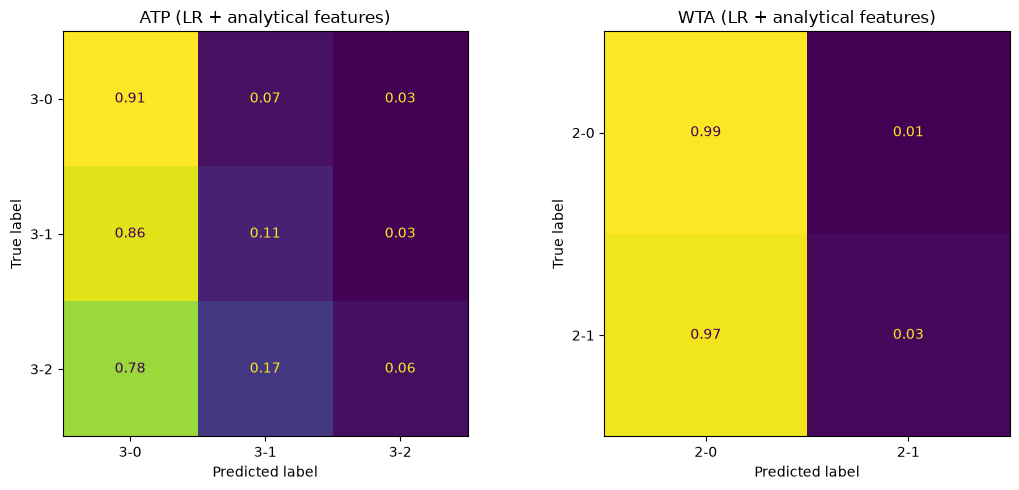

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, (tour, test) in zip(axes, [('ATP', atp_test), ('WTA', wta_test)]):
    cols = NUM_HYBRID[tour] + CATEGORICAL + PASSTHROUGH
    ConfusionMatrixDisplay.from_estimator(
        final_models[tour], test[cols], test['margin'], ax=ax, colorbar=False,
        normalize='true', values_format='.2f',
    )
    ax.set_title(f'{tour} (LR + analytical features)')
plt.tight_layout()
plt.savefig('../data/processed/confusion_matrix_margin.png', dpi=120)
plt.show()


## 8. Feature importance

In [14]:
def perm_importance(tour, test):
    cols = NUM_HYBRID[tour] + CATEGORICAL + PASSTHROUGH
    r = permutation_importance(final_models[tour], test[cols], test['margin'],
                                scoring='accuracy', n_repeats=10, random_state=0)
    return pd.DataFrame({'feature': cols, 'importance': r.importances_mean}).sort_values(
        'importance', ascending=False)

print('ATP top features:')
display(perm_importance('ATP', atp_test).head(8))
print('WTA top features:')
display(perm_importance('WTA', wta_test).head(8))


ATP top features:


,feature,importance
12,diff_pts_short_rally_share,0.003423
0,diff_elo,0.003012
21,analytical_p_five,0.002784
14,diff_pts_very_long_rally_share,0.002556
3,diff_form,0.002328
18,win_probability,0.002236
20,analytical_p_four,0.001871
2,diff_blended_elo,0.001324


WTA top features:


,feature,importance
0,diff_elo,0.008456
2,diff_blended_elo,0.002685
18,win_probability,0.002103
6,diff_seed,0.001924
1,diff_surface_elo,0.001521
3,diff_form,0.001342
22,round,0.000850
17,diff_avg_serve_speed_kmh,0.000761


## 9. Save


In [15]:
import os, re

os.makedirs('../models', exist_ok=True)
for (tour, name), pipeline in margin_models.items():
    if name == 'Majority-class baseline':
        continue
    safe_name = re.sub(r'[^a-z0-9]+', '_', name.lower()).strip('_')
    joblib.dump(pipeline, f'../models/margin_classifier_{tour.lower()}_{safe_name}.joblib')

atp.to_parquet('../data/processed/margin_dataset_atp.parquet', index=False)
wta.to_parquet('../data/processed/margin_dataset_wta.parquet', index=False)
results_df.to_csv('../data/processed/margin_classifier_results.csv', index=False)
print('saved models/ and data/processed/ outputs, including production model as')
print('models/margin_classifier_{atp,wta}_lr_analytical_features.joblib')


saved models/ and data/processed/ outputs, including production model as
models/margin_classifier_{atp,wta}_lr_analytical_features.joblib


## Summary

See `results_df` for the full comparison across every model tried: majority
baseline, plain logistic regression/gradient boosting, the pure analytical
(i.i.d.-sets) model, a neural net, ordinal logistic regression, stacking,
and the adopted production model (logistic regression enriched with the
analytical model's probabilities as extra features). As with the win
classifier, none of these differences are individually provable at this
test-set size — the production choice was made because it's the simplest
model that's at-or-near best on every metric, not because any single
comparison proves superiority.

The deeper finding of this notebook (section 5's "why is accuracy barely
above baseline") still stands regardless of which model is used: for "by
how much," the useful output is the full probability distribution over
margin buckets, not a forced single-class prediction.

**Next**: the two stages (win probability + margin) combine into a single
end-to-end prediction — given two players, output both "who wins" and "by
what scoreline" — plus the deferred data-viz piece now that there are real
model outputs (Elo trajectories, predictions) to visualize.
